## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

Notebook que implementa e compara modelos PyTorch para classificação de texto (Human vs AI):

1. **DNN Baseline** — Feedforward simples (Linear + ReLU + Dropout)
2. **DNN + BatchNorm** — Com Batch Normalization e Learning Rate Scheduling
3. **DNN Wide & Shallow** — Rede larga com menos camadas
4. **Comparação sistemática** de todas as variantes
5. **Avaliação final** — métricas, curvas, matrizes de confusão

### **1. Imports e Configuração**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time
from sklearn.metrics import confusion_matrix, classification_report

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))
from utils import prepare_text_data, transform_new_texts

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento e Preparação dos Dados**

In [2]:
print("A carregar os datasets...")

# Dataset de treino e validação
df_train_val = pd.read_csv('../data/dataset.csv', sep=';')
df_train_val.columns = df_train_val.columns.str.lower()
textos_train_val = df_train_val['text'].tolist()
labels_train_val = df_train_val['label'].tolist()

# Dataset de teste
df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset treino e validação: {len(textos_train_val)} textos")
print(f"  Dataset teste: {len(textos_test)} textos")

print("\nA processar features (TF-IDF word + char + estilísticas)...")
X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos_train_val,
    labels_train_val,
    max_features=1000,
    char_features=1000,
    val_size=0.2,
    use_stratify=True,
    ngram_range=(1, 2)
)

print("A processar features de teste...")
X_test = transform_new_texts(textos_test, transformers)
# O encoder custom espera uma sequência 1D de labels (strings), não array 2D reshape(-1,1)
Y_test_oh = encoder.transform(labels_test)

# Garantir formato numpy array denso
if hasattr(Y_test_oh, "toarray"):
    Y_test_oh = Y_test_oh.toarray()
Y_test_oh = np.asarray(Y_test_oh)

# Converter one-hot para índices (PyTorch CrossEntropyLoss espera índices)
y_train = np.argmax(Y_train_oh, axis=1)
y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)

# OneHotEncoder não tem atributo `.classes`; use `.categories_`
if hasattr(encoder, "categories_"):
    class_names = encoder.categories_[0]
elif hasattr(encoder, "classes_"):  # fallback (ex.: LabelEncoder)
    class_names = encoder.classes_
else:
    class_names = np.unique(np.array(labels_train_val))
print(f"\n✅ Classes: {list(class_names)}")
print(f"  Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}")

A carregar os datasets...
  Dataset treino e validação: 2500 textos
  Dataset teste: 125 textos

A processar features (TF-IDF word + char + estilísticas)...
A processar features de teste...

✅ Classes: [np.str_('Anthropic'), np.str_('Google'), np.str_('Human'), np.str_('Meta'), np.str_('OpenAI')]
  Treino: (2000, 2013) | Validação: (500, 2013) | Teste: (125, 2013)


#### **2.1 Conversão para Tensores PyTorch**

In [3]:
# Converter para tensores
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128, shuffle=False)

input_size = X_train_t.shape[1]
num_classes = len(class_names)
print(f"Input size: {input_size} | Classes: {num_classes} | Batch size: {BATCH_SIZE}")

Input size: 2013 | Classes: 5 | Batch size: 32


### **3. Função de Treino Genérica**

Uma única função que treina qualquer modelo PyTorch, com suporte a:
- Early stopping com restauração dos melhores pesos
- Learning rate scheduling (ReduceLROnPlateau)
- Registo de métricas (loss e accuracy para treino e validação)

In [4]:
def treinar_modelo(model, nome, epochs=150, lr=0.001, weight_decay=1e-4,
                   patience=15, use_scheduler=True):
    """
    Treina um modelo PyTorch e retorna métricas completas.
    
    Retorna: model, dict com resultados
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    print(f"{nome}")
    
    t0 = time.time()
    
    for epoch in range(epochs):
        # Treino
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_acc = correct_train / total_train
        
        # Validação 
        model.eval()
        val_loss_sum = 0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss_sum += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()
        
        avg_val_loss = val_loss_sum / len(val_loader)
        val_acc = correct_val / total_val
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if scheduler:
            scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"  Época {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%} | LR: {current_lr:.6f}")
        
        if patience_counter >= patience:
            print(f"  Early Stopping na época {epoch+1}!")
            break
    
    tempo = time.time() - t0
    
    # Restaurar melhores pesos
    if best_state:
        model.load_state_dict(best_state)
    
    # Avaliação final
    model.eval()
    with torch.no_grad():
        # Treino
        train_out = model(X_train_t)
        train_acc_final = (torch.argmax(train_out, 1) == y_train_t).float().mean().item()
        train_loss_final = criterion(train_out, y_train_t).item()
        # Validação
        val_out = model(X_val_t)
        val_acc_final = (torch.argmax(val_out, 1) == y_val_t).float().mean().item()
        val_loss_final = criterion(val_out, y_val_t).item()
        # Teste
        test_out = model(X_test_t)
        test_acc_final = (torch.argmax(test_out, 1) == y_test_t).float().mean().item()
        test_loss_final = criterion(test_out, y_test_t).item()
    
    print(f"\n  Treino    — Acc: {train_acc_final:.2%}")
    print(f"  Validação — Acc: {val_acc_final:.2%}")
    print(f"  Teste     — Acc: {test_acc_final:.2%}")
    print(f"  Tempo: {tempo:.1f}s")
    
    resultado = {
        'nome': nome,
        'train_acc': train_acc_final, 'val_acc': val_acc_final, 'test_acc': test_acc_final,
        'train_loss': train_loss_final, 'val_loss': val_loss_final, 'test_loss': test_loss_final,
        'tempo': tempo, 'history': history
    }
    
    return model, resultado

### **4. Definição dos Modelos**

Testamos 3 arquiteturas de DNN, todas com features tabulares (TF-IDF + estilísticas):

| Modelo | Arquitetura | Regularização |
|--------|-------------|---------------|
| **A — Baseline DNN** | 256 → 128 → 64 → 5 | Dropout(0.4, 0.3, 0.2) |
| **B — DNN + BatchNorm** | 256 → 128 → 64 → 5 | BatchNorm + Dropout(0.5, 0.4, 0.3) |
| **C — Wide & Shallow** | 512 → 64 → 5 | BatchNorm + Dropout(0.5, 0.3) |

In [5]:
# Modelo A: Baseline DNN 
class DNNBaseline(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)


# Modelo B: DNN + BatchNorm
class DNNBatchNorm(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)


# Modelo C: Wide & Shallow 
class DNNWide(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

print("Modelos definidos:")
for name, cls in [("A - Baseline", DNNBaseline), ("B - BatchNorm", DNNBatchNorm), ("C - Wide", DNNWide)]:
    m = cls(input_size, num_classes)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {name}: {n_params:,} parâmetros")

Modelos definidos:
  A - Baseline: 557,061 parâmetros
  B - BatchNorm: 557,957 parâmetros
  C - Wide: 1,065,477 parâmetros


### **5. Treino dos Modelos**

In [6]:
torch.manual_seed(42)
np.random.seed(42)

resultados = {}
modelos = {}

# Modelo A — Baseline
model_a, res_a = treinar_modelo(
    DNNBaseline(input_size, num_classes),
    "DNN A — Baseline",
    lr=0.001, weight_decay=1e-4
)
resultados['A'] = res_a
modelos['A'] = model_a

# Modelo B — BatchNorm
model_b, res_b = treinar_modelo(
    DNNBatchNorm(input_size, num_classes),
    "DNN B — BatchNorm + Dropout",
    lr=0.001, weight_decay=1e-4
)
resultados['B'] = res_b
modelos['B'] = model_b

# Modelo C — Wide
model_c, res_c = treinar_modelo(
    DNNWide(input_size, num_classes),
    "DNN C — Wide & Shallow",
    lr=0.001, weight_decay=1e-4
)
resultados['C'] = res_c
modelos['C'] = model_c

DNN A — Baseline
  Época  10/150 | Train Loss: 0.1331 | Val Loss: 0.6717 | Val Acc: 79.40% | LR: 0.001000
  Época  20/150 | Train Loss: 0.0169 | Val Loss: 0.7869 | Val Acc: 80.00% | LR: 0.000250
  Early Stopping na época 22!

  Treino    — Acc: 96.80%
  Validação — Acc: 78.00%
  Teste     — Acc: 60.80%
  Tempo: 7.9s
DNN B — BatchNorm + Dropout
  Época  10/150 | Train Loss: 0.2271 | Val Loss: 0.5609 | Val Acc: 79.40% | LR: 0.001000
  Época  20/150 | Train Loss: 0.0687 | Val Loss: 0.6250 | Val Acc: 79.80% | LR: 0.000250
  Early Stopping na época 21!

  Treino    — Acc: 98.90%
  Validação — Acc: 80.00%
  Teste     — Acc: 51.20%
  Tempo: 8.3s
DNN C — Wide & Shallow
  Época  10/150 | Train Loss: 0.1001 | Val Loss: 0.6145 | Val Acc: 78.40% | LR: 0.001000
  Época  20/150 | Train Loss: 0.0394 | Val Loss: 0.6712 | Val Acc: 78.20% | LR: 0.000250
  Early Stopping na época 20!

  Treino    — Acc: 99.75%
  Validação — Acc: 79.20%
  Teste     — Acc: 60.80%
  Tempo: 9.6s


### **6. Exploração de Hiperparâmetros**

Com a melhor arquitetura, testamos diferentes combinações de learning rate e weight decay.

In [7]:
# Testar variações de hiperparâmetros na arquitetura BatchNorm
configs = [
    ("B-lr0.0005",      0.0005, 1e-4),
    ("B-lr0.001-wd0",   0.001,  0.0),
    ("B-lr0.001-wd1e-3", 0.001, 1e-3),
]

for nome_cfg, lr_cfg, wd_cfg in configs:
    torch.manual_seed(42)
    model_hp, res_hp = treinar_modelo(
        DNNBatchNorm(input_size, num_classes),
        f"DNN B — LR={lr_cfg}, WD={wd_cfg}",
        lr=lr_cfg, weight_decay=wd_cfg
    )
    resultados[nome_cfg] = res_hp
    modelos[nome_cfg] = model_hp

DNN B — LR=0.0005, WD=0.0001
  Época  10/150 | Train Loss: 0.2317 | Val Loss: 0.5822 | Val Acc: 78.20% | LR: 0.000500
  Época  20/150 | Train Loss: 0.0936 | Val Loss: 0.5807 | Val Acc: 81.20% | LR: 0.000125
  Early Stopping na época 22!

  Treino    — Acc: 98.55%
  Validação — Acc: 79.80%
  Teste     — Acc: 62.40%
  Tempo: 8.7s
DNN B — LR=0.001, WD=0.0
  Época  10/150 | Train Loss: 0.2305 | Val Loss: 0.6002 | Val Acc: 79.40% | LR: 0.001000
  Época  20/150 | Train Loss: 0.0892 | Val Loss: 0.6181 | Val Acc: 80.80% | LR: 0.000250
  Early Stopping na época 22!

  Treino    — Acc: 99.20%
  Validação — Acc: 78.60%
  Teste     — Acc: 61.60%
  Tempo: 8.3s
DNN B — LR=0.001, WD=0.001
  Época  10/150 | Train Loss: 0.2418 | Val Loss: 0.6216 | Val Acc: 77.80% | LR: 0.001000
  Época  20/150 | Train Loss: 0.0966 | Val Loss: 0.6008 | Val Acc: 81.00% | LR: 0.000250
  Early Stopping na época 21!

  Treino    — Acc: 98.60%
  Validação — Acc: 79.20%
  Teste     — Acc: 52.00%
  Tempo: 8.6s


### **7. Curvas de Aprendizagem**

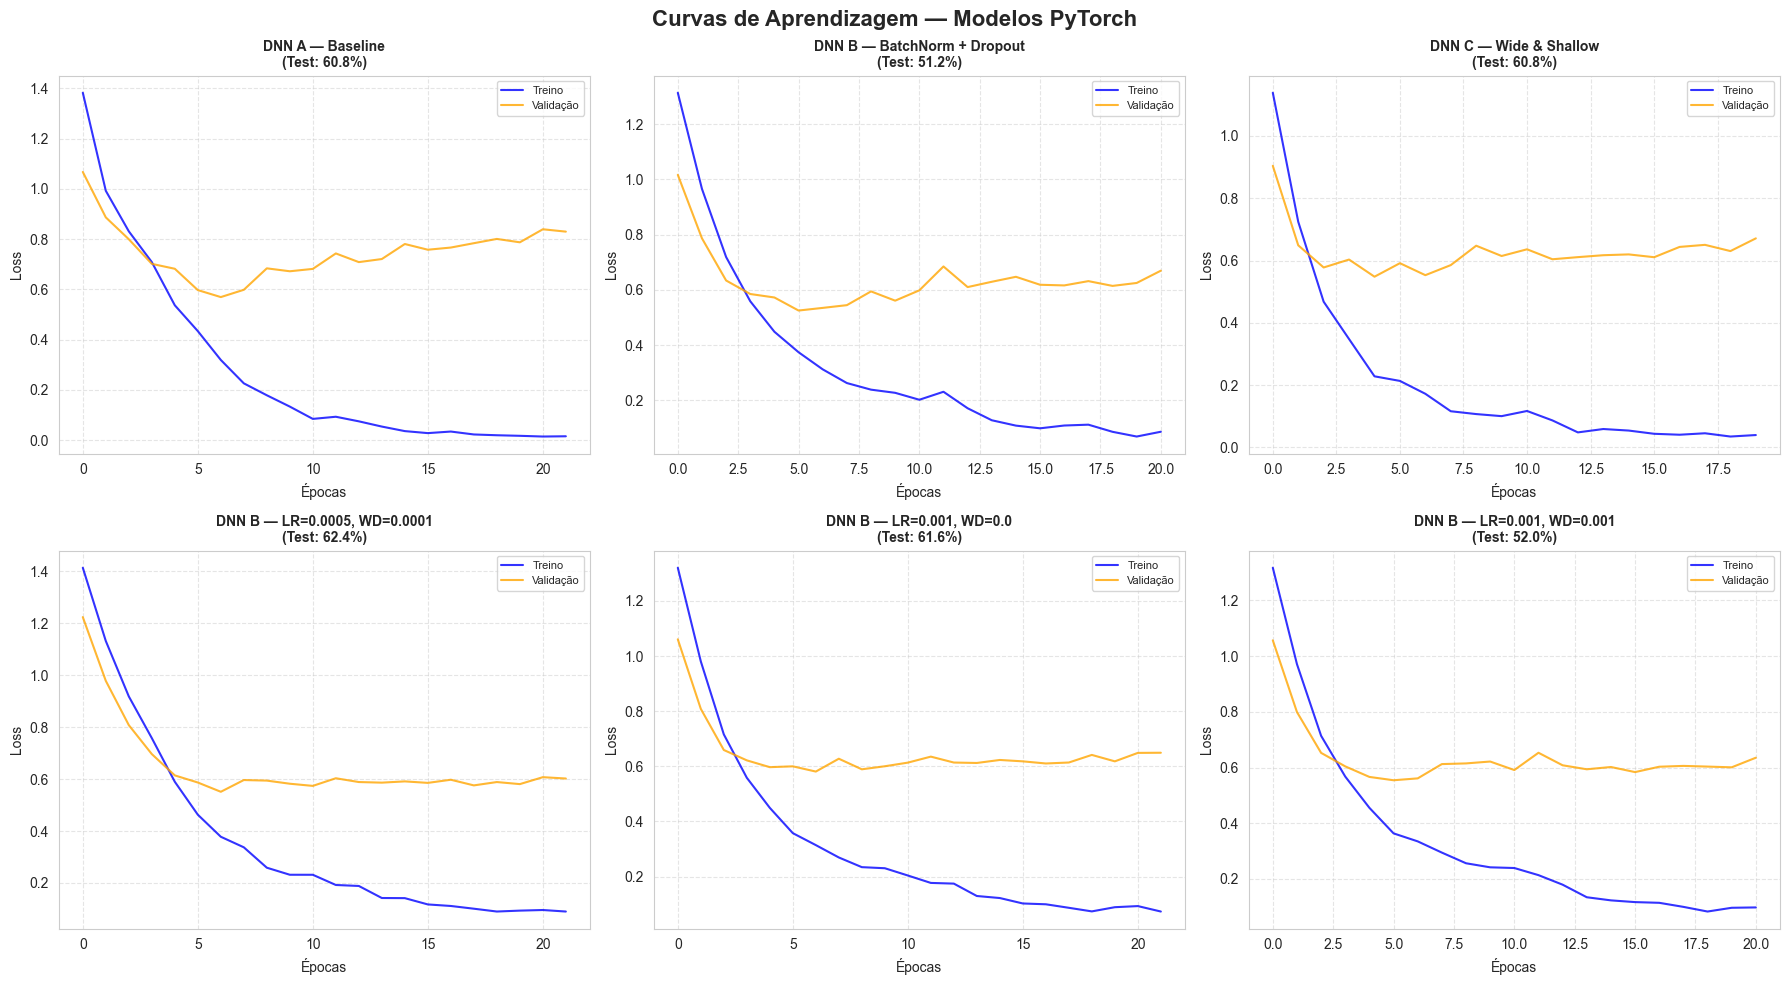

In [8]:
# Plotar curvas dos 3 modelos principais + variantes
modelos_plot = [(k, v) for k, v in resultados.items()]
n_plots = len(modelos_plot)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = axes.flatten()

for idx, (key, res) in enumerate(modelos_plot):
    ax = axes[idx]
    ax.plot(res['history']['train_loss'], label='Treino', color='blue', alpha=0.8)
    ax.plot(res['history']['val_loss'], label='Validação', color='orange', alpha=0.8)
    ax.set_title(f"{res['nome']}\n(Test: {res['test_acc']:.1%})", fontweight='bold', fontsize=10)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

# Esconder subplots vazios
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Curvas de Aprendizagem — Modelos PyTorch', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **8. Comparação de Todos os Modelos**

In [9]:
rows = []
for key, res in resultados.items():
    rows.append({
        'Modelo': res['nome'],
        'Train Acc': f"{res['train_acc']:.2%}",
        'Val Acc': f"{res['val_acc']:.2%}",
        'Test Acc': f"{res['test_acc']:.2%}",
        'Test Loss': f"{res['test_loss']:.4f}",
        'Tempo (s)': f"{res['tempo']:.1f}",
    })

df_resultados = pd.DataFrame(rows)
df_resultados = df_resultados.sort_values('Test Acc', ascending=False)
print(df_resultados.to_string(index=False))

                      Modelo Train Acc Val Acc Test Acc Test Loss Tempo (s)
DNN B — LR=0.0005, WD=0.0001    98.55%  79.80%   62.40%    1.1276       8.7
    DNN B — LR=0.001, WD=0.0    99.20%  78.60%   61.60%    1.3825       8.3
            DNN A — Baseline    96.80%  78.00%   60.80%    2.1408       7.9
      DNN C — Wide & Shallow    99.75%  79.20%   60.80%    1.4143       9.6
  DNN B — LR=0.001, WD=0.001    98.60%  79.20%   52.00%    1.6728       8.6
 DNN B — BatchNorm + Dropout    98.90%  80.00%   51.20%    1.4676       8.3


### **9. Avaliação do Melhor Modelo**

In [10]:
# Selecionar melhor modelo
melhor_key = max(resultados, key=lambda k: resultados[k]['test_acc'])
melhor_res = resultados[melhor_key]
melhor_model = modelos[melhor_key]

print(f"🏆 Melhor modelo: {melhor_res['nome']}")
print(f"   Test Accuracy: {melhor_res['test_acc']:.2%}")

# Previsões
melhor_model.eval()
with torch.no_grad():
    outputs = melhor_model(X_test_t)
    _, predicted = torch.max(outputs, 1)

y_true = y_test_t.cpu().numpy()
y_pred = predicted.cpu().numpy()

🏆 Melhor modelo: DNN B — LR=0.0005, WD=0.0001
   Test Accuracy: 62.40%


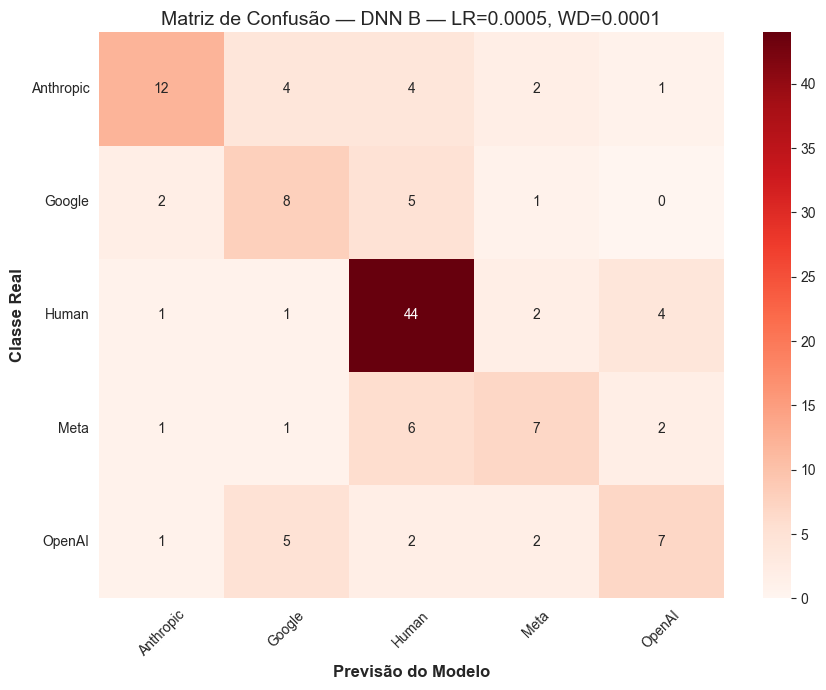


Classification Report — DNN B — LR=0.0005, WD=0.0001:
              precision    recall  f1-score   support

   Anthropic       0.71      0.52      0.60        23
      Google       0.42      0.50      0.46        16
       Human       0.72      0.85      0.78        52
        Meta       0.50      0.41      0.45        17
      OpenAI       0.50      0.41      0.45        17

    accuracy                           0.62       125
   macro avg       0.57      0.54      0.55       125
weighted avg       0.62      0.62      0.62       125



In [11]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_res["nome"]}', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report — {melhor_res['nome']}:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

## 10. Guardar o Modelo para Submissão

In [12]:
import pickle

os.makedirs('../models', exist_ok=True)

# Guardar o modelo PyTorch (.pth)
model_path = '../models/pytorch.pth'
torch.save(melhor_model.state_dict(), model_path)
print(f"✅ Pesos do modelo guardados em '{model_path}'")

# Guardar os transformadores e metadados (para reconstruir na submissão)
meta = {
    'model_class': melhor_model.__class__.__name__,
    'input_size': input_size,
    'num_classes': num_classes,
    'class_names': list(class_names),
    'transformers': transformers,
    'encoder': encoder,
    'melhor_resultado': {k: v for k, v in melhor_res.items() if k != 'history'},
}

meta_path = '../models/pytorch.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f"✅ Metadados guardados em '{meta_path}'")

# Resumo
print(f"\n📋 Para submissão, usar:")
print(f"   1. Carregar meta de '{meta_path}'")
print(f"   2. Reconstruir modelo {meta['model_class']}(input_size={input_size}, num_classes={num_classes})")
print(f"   3. model.load_state_dict(torch.load('{model_path}'))")
print(f"   4. Transformar textos com transform_new_texts(textos, meta['transformers'])")

✅ Pesos do modelo guardados em '../models/pytorch.pth'
✅ Metadados guardados em '../models/pytorch.pkl'

📋 Para submissão, usar:
   1. Carregar meta de '../models/pytorch.pkl'
   2. Reconstruir modelo DNNBatchNorm(input_size=2013, num_classes=5)
   3. model.load_state_dict(torch.load('../models/pytorch.pth'))
   4. Transformar textos com transform_new_texts(textos, meta['transformers'])
